End-to-End Sales Forecasting & Demand Intelligence System


In [2]:
#IMPORTING LIBRARIES

#Data Manipulation

import pandas as pd 
import numpy as np

#Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

#Configure plots
plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (12, 6)
sns.set_theme(style="whitegrid")

#Ignore warnings
import warnings
warnings.filterwarnings("ignore")

Task 1 — Data Loading, Merging & Deep Exploration

In [3]:
#Load the dataset (Superstore Sales Dataset)
df = pd.read_csv("data/train.csv")

#Display first 5 rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
#Information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [5]:
#Statistical Summary (descriptive summary)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Row ID,9800.0,4900.500000,2829.160653,1.000,2450.750,4900.50,7350.250,9800.00
Postal Code,9789.0,55273.322403,32041.223413,1040.000,23223.000,58103.00,90008.000,99301.00
Sales,9800.0,230.769059,626.651875,0.444,17.248,54.49,210.605,22638.48


In [6]:
#Missing value analysis (check for null values in every feature)

missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df)) * 100
})
missing.sort_values("Missing Values", ascending=False)

,Missing Values,Percentage
Postal Code,11,0.112245
Row ID,0,0.000000
Order ID,0,0.000000
Order Date,0,0.000000
Ship Mode,0,0.000000
Ship Date,0,0.000000
Customer Name,0,0.000000
Segment,0,0.000000
Country,0,0.000000
Customer ID,0,0.000000


In [7]:
#Duplicate record analysis (Identify duplicate record analysis)

duplicates = df.duplicated().sum()  
print(f"Duplicate Records : {duplicates}")

Duplicate Records : 0


In [8]:
#Checking date format in order date and ship date

df[["Order Date", "Ship Date"]].head(10)

,Order Date,Ship Date
0,08/11/2017,11/11/2017
1,08/11/2017,11/11/2017
2,12/06/2017,16/06/2017
3,11/10/2016,18/10/2016
4,11/10/2016,18/10/2016
5,09/06/2015,14/06/2015
6,09/06/2015,14/06/2015
7,09/06/2015,14/06/2015
8,09/06/2015,14/06/2015
9,09/06/2015,14/06/2015


In [9]:
#Check for invalid dates

pd.to_datetime(
    df["Order Date"],
    format="%d/%m/%Y",
    errors="coerce"
).isna().sum()

np.int64(0)

In [10]:
#Display problematic rows

invalid_dates = df[
    pd.to_datetime(
        df["Order Date"],
        format="%d/%m/%Y",
        errors="coerce"
    ).isna()
]

invalid_dates[["Order Date"]].head(20)

,Order Date


In [11]:
#Date Parsing (converting order date and ship date into datetime format)

df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format="mixed",
    dayfirst=True
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    format="mixed",
    dayfirst=True
)

In [12]:
#Check data types of Order Date and Ship Date after date parsing

df[["Order Date", "Ship Date"]].dtypes


Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object

In [13]:
#Display first 5 rows after date parsing

df[["Order Date", "Ship Date"]].head()

,Order Date,Ship Date
0,2017-11-08,2017-11-11
1,2017-11-08,2017-11-11
2,2017-06-12,2017-06-16
3,2016-10-11,2016-10-18
4,2016-10-11,2016-10-18


In [14]:
#Feature Engineering 
#Extracting time based features from Order Date column

df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()
df["Week"] = df["Order Date"].dt.isocalendar().week.astype(int)
df["Day"] = df["Order Date"].dt.day_name()
df["Quarter"] = df["Order Date"].dt.quarter

In [15]:
#Season

def get_season(month):
    if month in[12,1,2]:
        return "Winter"
    elif month in[3,4,5]:
        return "Spring"
    elif month in[6,7,8]:
        return "Summer"
    else:
        return "Autumn"

df["Season"] = df["Month"].apply(get_season)


In [ ]:
#Shipping Time
#Shipping duration between order placement and shipment

df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

In [ ]:
#Weekly & Monthly Aggregation
#Weekly sales

weekly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"]
    .sum()
    .reset_index()
)
weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [ ]:
#Monthly sales

monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq = "M"))["Sales"]
    .sum()
    .reset_index()
)
monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


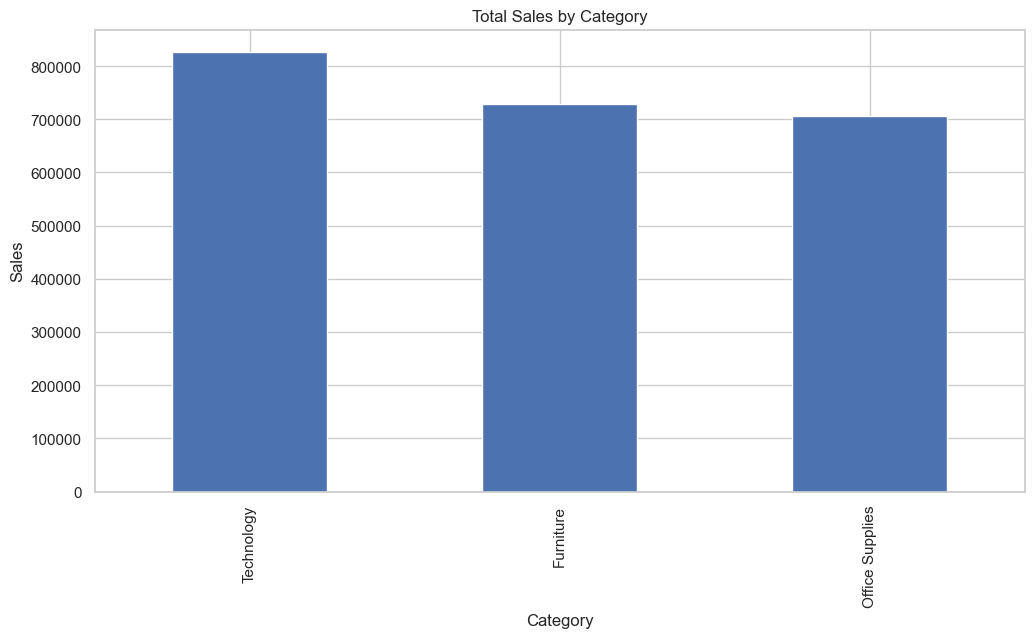

In [ ]:
#Exploratory Data Analysis (EDA)
#Category wise sales

category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)
category_sales.plot(kind="bar")
plt.title("Total Sales by Category")
plt.ylabel("Sales")
plt.show()

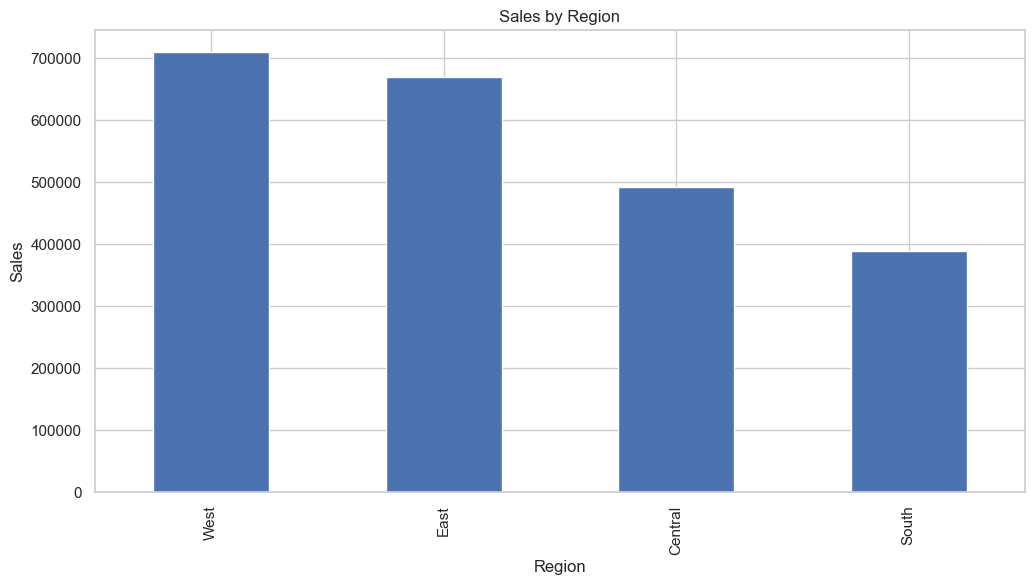

In [33]:
#Region-wise sales

region_sales = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

region_sales.plot(kind="bar")
plt.title("Sales by Region")
plt.ylabel("Sales")
plt.show()

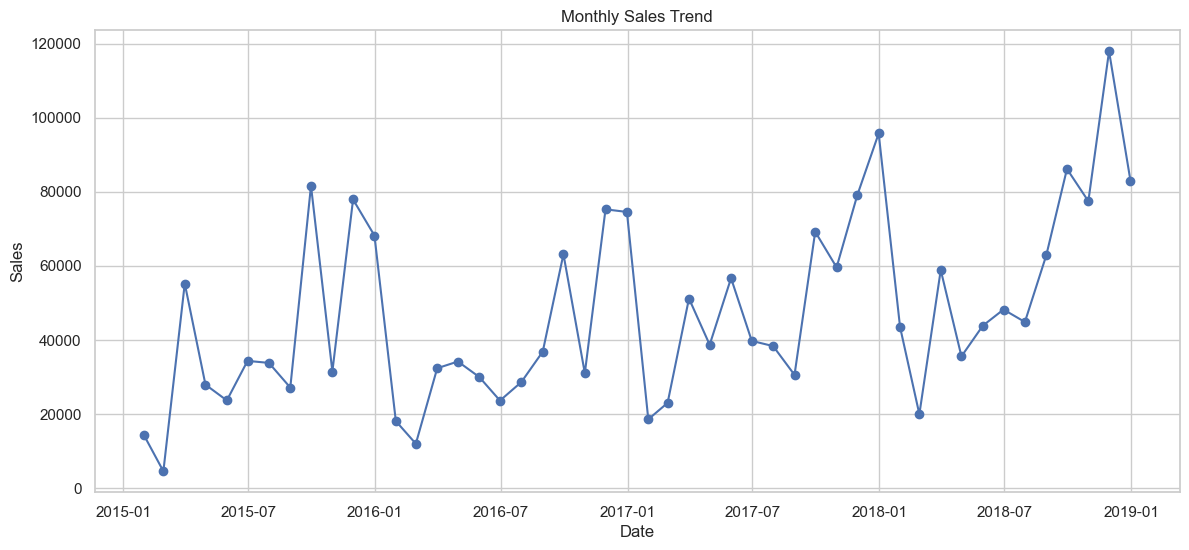

In [ ]:
#Monthly sales trend

plt.figure(figsize=(14,6))
plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    marker = "o"
)
plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

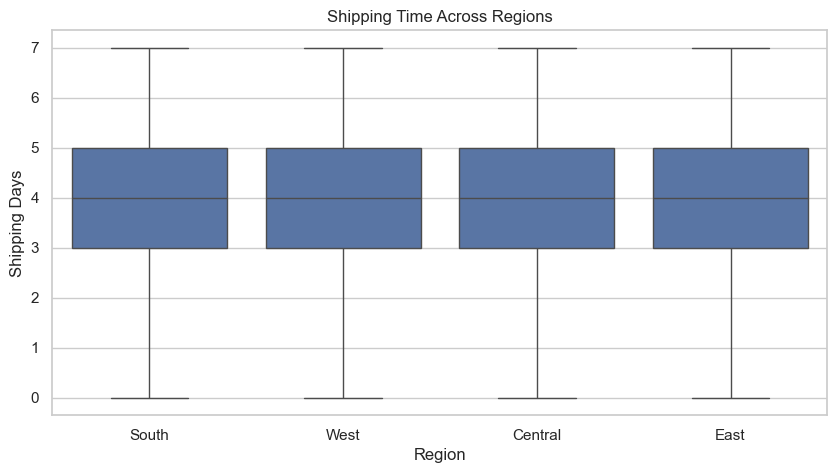

In [ ]:
#Shipping time by region

plt.figure(figsize=(10,5))
sns.boxplot(
    x="Region",
    y="Shipping Days",
    data = df
)
plt.title("Shipping Time Across Regions")
plt.show()

Buisness Questions


# 1. Which category genrates highest revenue? 
- category_sales
- Technology generates the highest overall revenue, followed by Furniture and Office Supplies.

# 2. Which region has the most consistent sales growth?

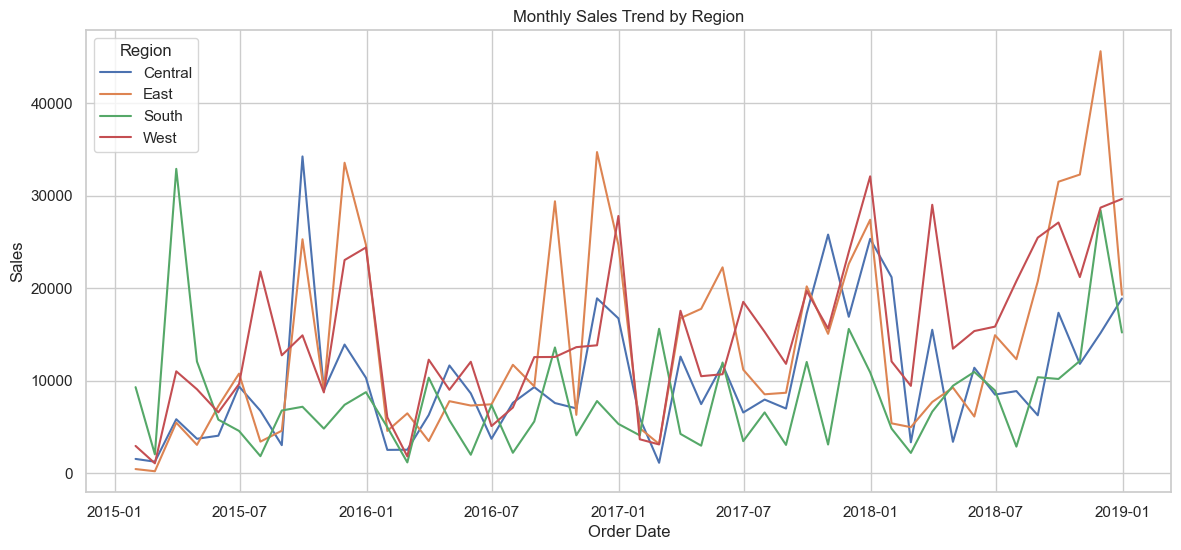

In [ ]:

regional_monthly = (
    df.groupby([
        pd.Grouper(key="Order Date", freq ="M"),
        "Region"
    ])["Sales"]
    .sum()
    .reset_index()
)
plt.figure(figsize=(14,6))
sns.lineplot(
    data = regional_monthly,
    x ="Order Date",
    y = "Sales",
    hue = "Region"
)
plt.title("Monthly Sales Trend by Region")
plt.show()


The west region demonstrates the most consistent upward sales trend over the four-year period.

# 3. What is the average time between Order Date and Ship Date — and does vary by region?

In [ ]:

df.groupby("Region")["Shipping Days"].mean().sort_values()

Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: Shipping Days, dtype: float64

# 4. Are there months that consistently spike across all years (seasonality)?


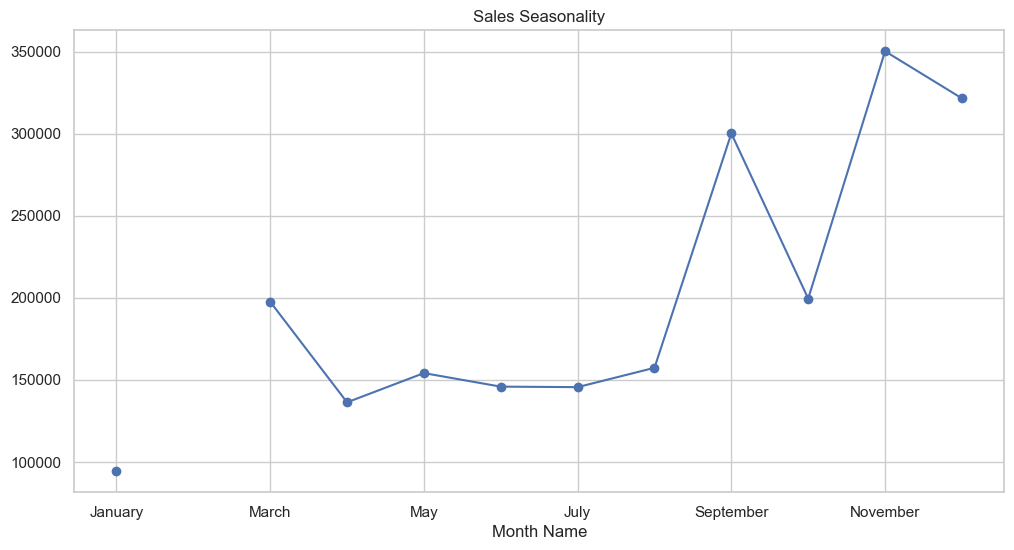

In [ ]:

seasonality = (
    df.groupby("Month Name")["Sales"]
    .sum()
    .reindex([
        "January","Feburary","March","April","May","June","July","August",
        "September","October","November","December"
    ])
)
seasonality.plot(marker="o")
plt.title("Sales Seasonality")
plt.show()

Task 1 Summary

- Successfully loaded and cleaned the Superstore Sales dataset.

- Converted data columns into datetime format.

- Created additional temporal features including Year, Month, Week, Quarter, Day, and Season.

- Calculated shipping duration for each transaction.

- Aggregated sales into weekly and monthly levels for future forecasting.

- Identified sales distribution across product categories and regions.

- Examoned shipping performance across different regions.

- Explored monthly sales trends and seasonal behaviour.

Task 2 — Time Series Analysis & Decomposition

In [ ]:


monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq = "ME"))["Sales"]
    .sum()
    .reset_index()
)
monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


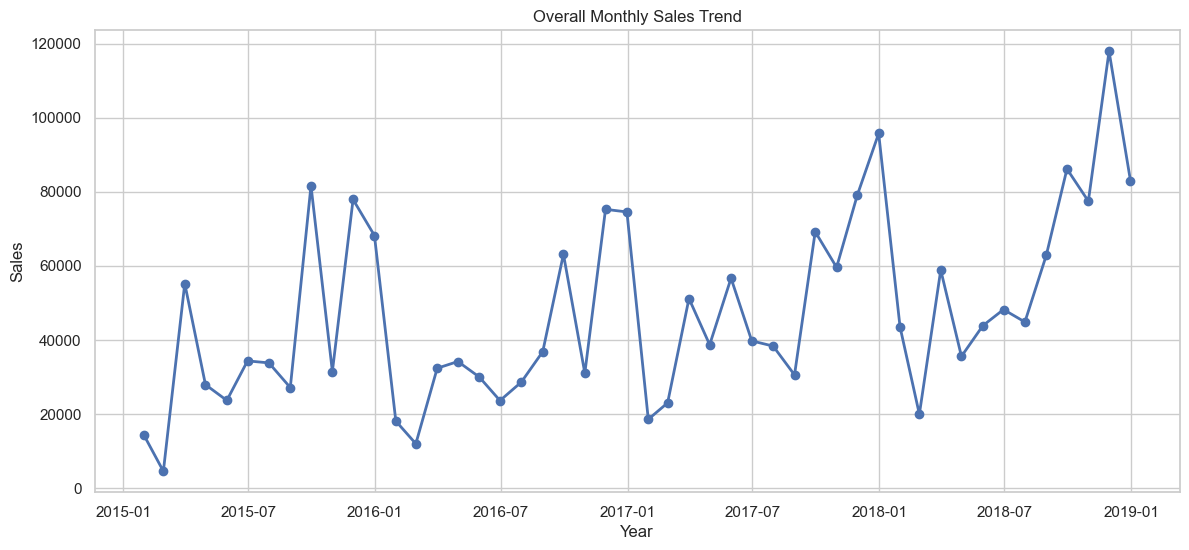

In [26]:
plt.figure(figsize=(14,6))
plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    marker="o",
    linewidth=2
)

plt.title("Overall Monthly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.show()

In [27]:
monthly_sales.set_index("Order Date", inplace=True)
monthly_sales.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


In [28]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposiiton = seasonal_decompose(
    monthly_sales["Sales"],
    model= "additive",
    period=12
)

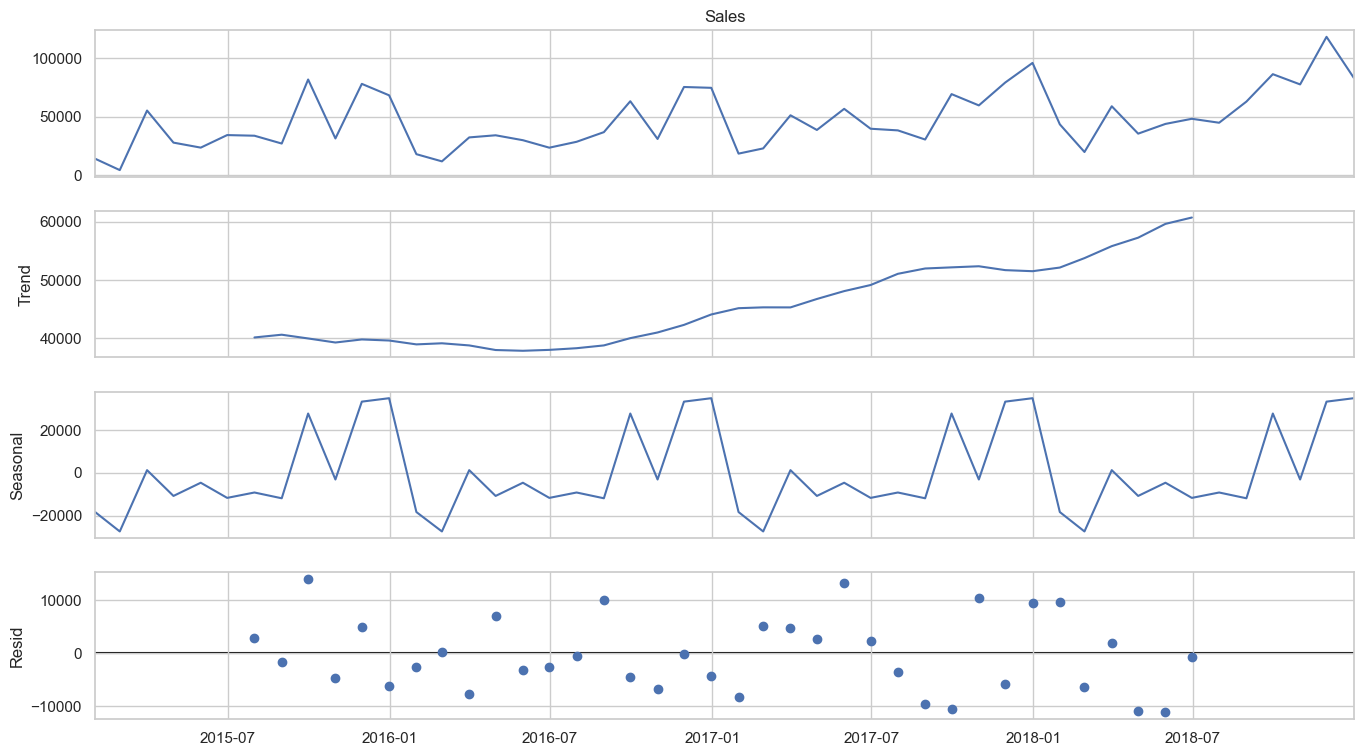

In [29]:
fig = decomposiiton.plot()
fig.set_size_inches(14,8)
plt.show()

### Observations

- Trend: Shows the long-term increase or decrease in sales.
- Seasonality: Repeating yearly patterns in monthly sales.
- Residual: Random fluctuations that are not explained by the trend or seasonality.

The decomposition helps determine whether the data contains a strong seasonal pattern, which is important when selecting forecasting models.

In [30]:
#Statinary Test (ADF Test)
#The ADF Test checks ehther the time is stationary. 

from statsmodels.tsa.stattools import adfuller
result = adfuller(monthly_sales["Sales"])

print("ADF Statistic :", result[0])
print("p-value :", result[1])
print("Critical Values:")

for key, value in result[4].items():
    print(f"{key}: {value}")

ADF Statistic : -4.416136761430769
p-value : 0.00027791039276670623
Critical Values:
1%: -3.5778480370438146
5%: -2.925338105429433
10%: -2.6007735310095064


In [31]:
if result[1] < 0.05:
    print("The time series is stationary.")
else:
    print("The time series is NOT stationary")

The time series is stationary.


### Interpretation
- p-value < 0.05 : The series is stationary.
- p-value >= 0.05 : The series is non-stationary and should be transformed brfore applying many forecasting models.

In [32]:
monthly_sales["Differenced Sales"] = (
    monthly_sales["Sales"].diff()
)
monthly_sales.drop(
    columns=["Differencing Sales", "DifferencedSales"],
    inplace=True
)

monthly_sales.head()

KeyError: "['Differencing Sales', 'DifferencedSales'] not found in axis"

In [ ]:
differenced = monthly_sales["Differenced Sales"].dropna()

In [ ]:
result2 = adfuller(differenced)
print("ADF Statistic :", result2[0])
print("p-value :", result2[1])

for key, value in result2[4].items():
    print(f"{key}: {value}")

ADF Statistic : -8.72706183035327
p-value : 3.2669175472796045e-14
1%: -3.626651907578875
5%: -2.9459512825788754
10%: -2.6116707716049383


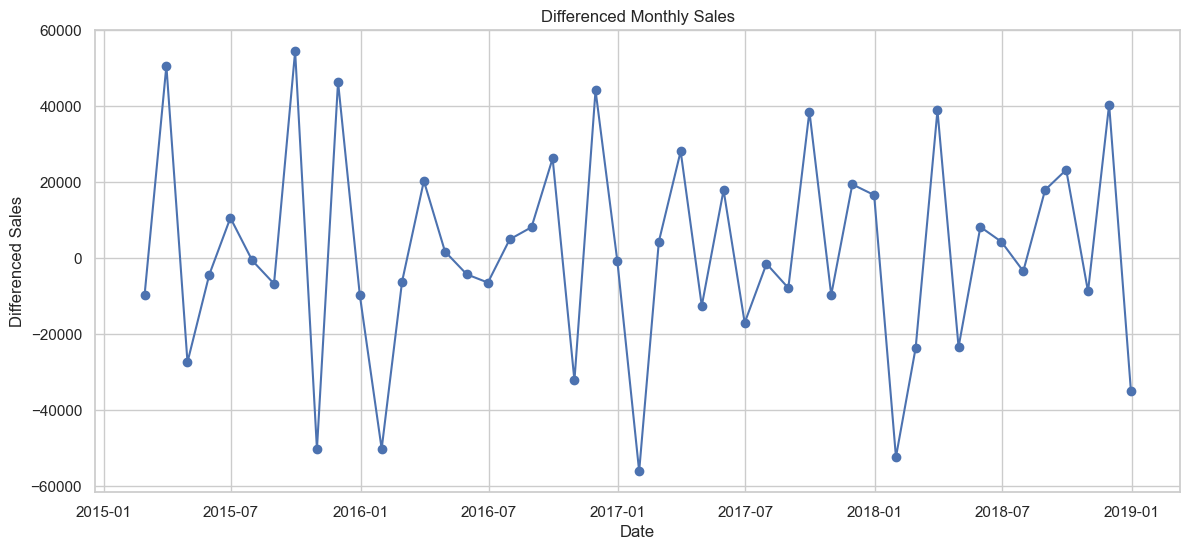

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    differenced, 
    marker="o"
)
plt.title("Differenced Monthly Sales")
plt.xlabel("Date")
plt.ylabel("Differenced Sales")

plt.grid(True)
plt.show()

In [ ]:
#Monthly sales trend
plt.savefig("charts/monthly_sales_trend.png", dpi=300, bbox_inches="tight")

#Decomposition plot
fig.savefig("charts/time_series_decomposition.png", dpi=300, bbox_inches="tight")

#Differenced series
fig.savefig("charts/differenced_series.png", dpi=300, bbox_inches="tight")

<Figure size 1200x600 with 0 Axes>

Task 2 Summary:

- Monthly sales were aggregated and visualized to observe the long-term trend.
- Time series decompostion separated the sales signal into trend, seasonal, and residual components.
- The ADF test was used to evaluate stationary.
- Since the origina series was non-stationary, first-order differencing was applied.
- The differenced series showed improved stationary, making it more suitable for forecasting models such as SARIMA.